# Task 26: Assignment

Q1. (Understanding & Dataset Creation)

Create a synthetic dataset using make_blobs with:

n_samples=500

centers=4

cluster_std=0.70

Convert it into a DataFrame with column names Feature1 and Feature2.

Display the first 10 rows and the shape of the dataset.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# Create synthetic dataset
X, y = make_blobs(n_samples=500, centers=4, cluster_std=0.70, random_state=42)

# Convert into a DataFrame
df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])

# Display shape and first 10 rows
print("Shape of Dataset:", df.shape)
print("\nFirst 10 Rows:")
print(df.head(10))

Shape of Dataset: (500, 2)

First 10 Rows:
   Feature1  Feature2
0 -8.033836  6.831299
1 -8.767448 -6.918116
2  6.172741  1.407361
3 -2.783673  7.989826
4 -6.038777 -7.165762
5 -6.298392 -7.479368
6 -7.046269  7.256281
7 -6.690307 -6.915276
8  3.892545  1.873504
9 -7.317000 -6.861846


Q2. (Data Scaling)

Apply Standard Scaling on the features created in Q1.

Use StandardScaler from sklearn.

Store the scaled data in X_scaled.

Show the first 5 rows of the scaled data.


In [3]:
# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['Feature1', 'Feature2']])

# Show first 5 rows of scaled data
print("First 5 rows of X_scaled:")
print(X_scaled[:5])

First 5 rows of X_scaled:
[[-0.88847363  0.62990684]
 [-1.02890768 -1.56287499]
 [ 1.83106858 -0.23511276]
 [ 0.11655663  0.81467072]
 [-0.5065627  -1.60237008]]


Q3. (Basic K-Means Clustering)

Apply KMeans clustering with n_clusters=3 on the scaled data.

Fit the model and predict cluster labels.

Add the cluster labels as a new column in the DataFrame.

Display the first 10 rows of the updated DataFrame.


In [4]:
# Apply KMeans with n_clusters = 3
kmeans_3 = KMeans(n_clusters=3, random_state=42)
df['Cluster_K3'] = kmeans_3.fit_predict(X_scaled)

# Display first 10 rows of updated DataFrame
print("First 10 rows with Cluster_K3:")
print(df.head(10))

First 10 rows with Cluster_K3:
   Feature1  Feature2  Cluster_K3
0 -8.033836  6.831299           1
1 -8.767448 -6.918116           2
2  6.172741  1.407361           0
3 -2.783673  7.989826           1
4 -6.038777 -7.165762           2
5 -6.298392 -7.479368           2
6 -7.046269  7.256281           1
7 -6.690307 -6.915276           2
8  3.892545  1.873504           0
9 -7.317000 -6.861846           2


c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

Q4. (Visualizing Clusters)

Create a scatter plot using seaborn to visualize the clusters formed in Q3.

Use Feature1 on x-axis and Feature2 on y-axis.

Color the points based on the cluster labels (hue).

Add a proper title and labels to the plot.


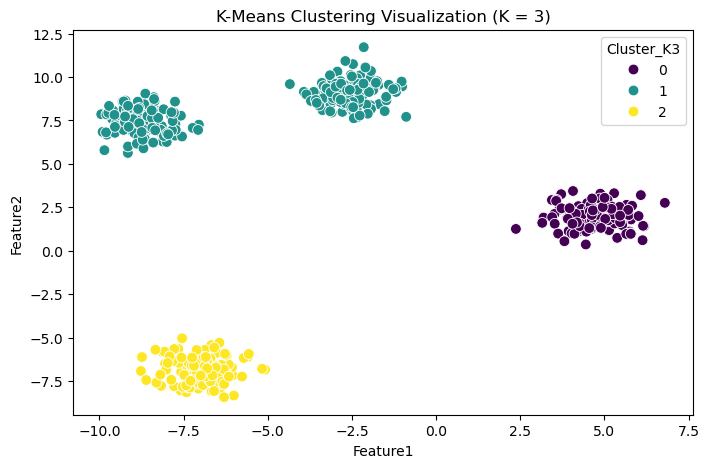

In [5]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Feature1', y='Feature2', hue='Cluster_K3', data=df, palette='viridis', s=60)
plt.title('K-Means Clustering Visualization (K = 3)')
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.show()

Q5. (Elbow Method – Finding Optimal K)

Implement the Elbow Method to find the best number of clusters:

Try K values from 1 to 10.

Calculate and store the inertia (WSS) for each K.

Plot the Elbow graph (K vs Inertia) with markers.

Observe the graph and write which K value looks optimal.


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

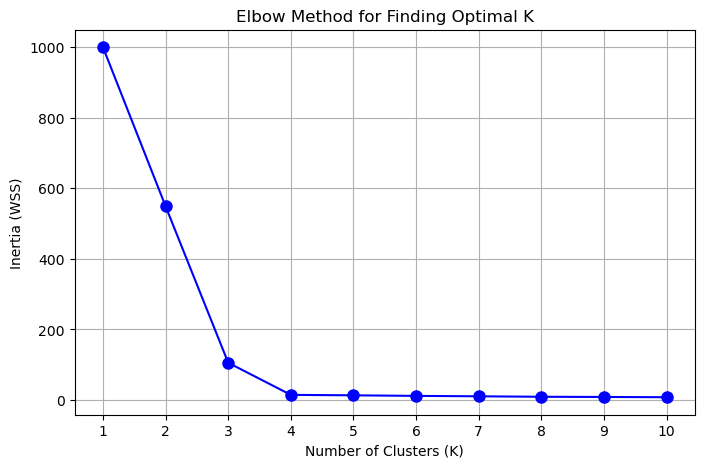

In [6]:
# Calculate inertia for K from 1 to 10
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-', markersize=8)
plt.title('Elbow Method for Finding Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WSS)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

# Observation: 
# Looking at the plot, the "elbow" point is at K = 4. 
# Beyond K = 4, the reduction in inertia levels off significantly.

Q6. (Final K-Means Model)

Based on the Elbow Method result from Q5:

Train a final KMeans model with the optimal number of clusters.

Use random_state=42.

Predict the cluster labels and add them to the DataFrame.

Print the number of data points in each cluster.


In [7]:
# Train final model with optimal K = 4
kmeans_final = KMeans(n_clusters=4, random_state=42)
df['Final_Cluster'] = kmeans_final.fit_predict(X_scaled)

# Print number of data points in each cluster
print("Data points in each cluster:")
print(df['Final_Cluster'].value_counts())

Data points in each cluster:
Final_Cluster
1    125
2    125
0    125
3    125
Name: count, dtype: int64


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Q7. (Visualizing Final Clusters)

Create a clear scatter plot of the final clusters obtained in Q6.

Use different colors for each cluster.

Add cluster centroids to the plot (optional but recommended).

Give a proper title: “K-Means Clustering Results”.

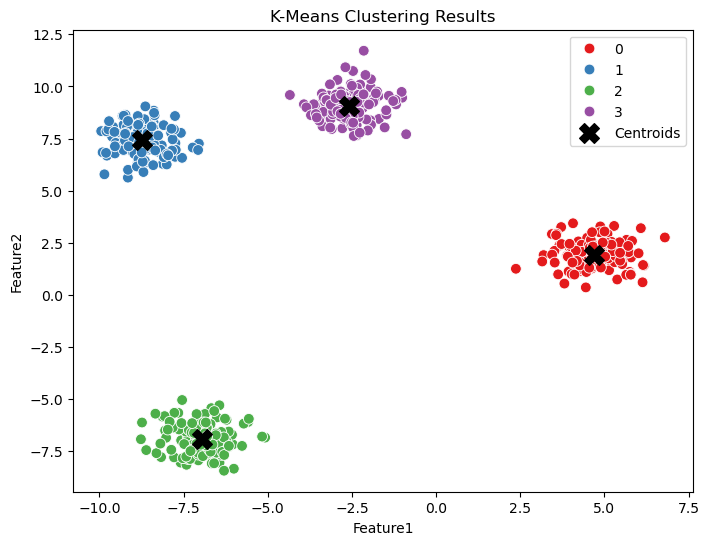

In [16]:
plt.figure(figsize=(8, 6))

# Plot clusters
sns.scatterplot(x='Feature1', y='Feature2', hue='Final_Cluster', data=df, palette='Set1', s=60)

# Calculate and plot cluster centroids in original scale
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

plt.scatter(centroids_original[:, 0], centroids_original[:, 1], 
            c='black', marker='X', s=200, label='Centroids')

plt.title('K-Means Clustering Results')
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.legend()
plt.show()

Q8. (Real Dataset Application)

Load any real-world dataset suitable for clustering (e.g., Iris, Mall Customers, or
any dataset of your choice).

Select only numerical features.

Scale the data.

Apply KMeans with a suitable number of clusters.

Add cluster labels to the DataFrame and show value counts of each cluster.


In [9]:
# 1. Load Iris dataset
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)

# 2. Select numerical features (all features are numerical)
X_iris = df_iris.copy()

# 3. Scale the data
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

# 4. Apply KMeans (n_clusters = 3)
kmeans_iris = KMeans(n_clusters=3, random_state=42)
df_iris['Cluster'] = kmeans_iris.fit_predict(X_iris_scaled)

# 5. Show value counts
print("Value counts for each cluster (Iris):")
print(df_iris['Cluster'].value_counts())

Value counts for each cluster (Iris):
Cluster
0    96
1    33
2    21
Name: count, dtype: int64


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Q9. (Elbow Method on Real Dataset)

On the real dataset used in Q8:

Apply the Elbow Method (K = 1 to 10).

Plot the Elbow curve.

Decide the optimal K and train the final KMeans model.

Visualize the clusters (if the dataset has 2 main features) or print cluster sizes.


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

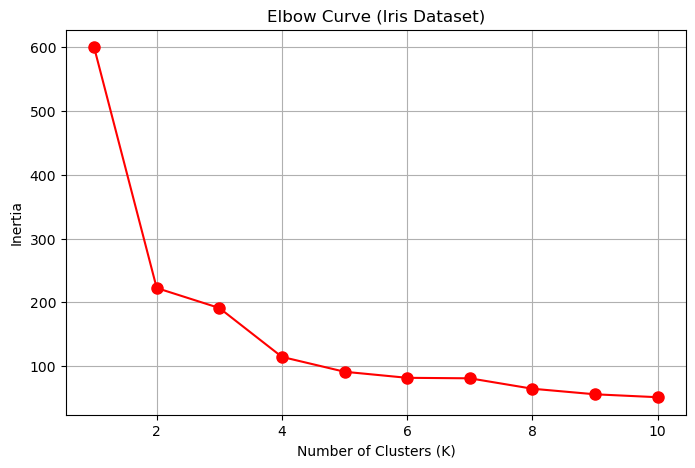

Final Cluster Sizes (Iris):
Final_Cluster
0    96
1    33
2    21
Name: count, dtype: int64


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [10]:
# 1. Apply Elbow Method (K = 1 to 10)
inertia_iris = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_iris_scaled)
    inertia_iris.append(km.inertia_)

# 2. Plot Elbow curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia_iris, 'ro-', markersize=8)
plt.title('Elbow Curve (Iris Dataset)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# 3. Decide optimal K (K = 3) and train final model
kmeans_iris_final = KMeans(n_clusters=3, random_state=42)
df_iris['Final_Cluster'] = kmeans_iris_final.fit_predict(X_iris_scaled)

# 4. Print cluster sizes
print("Final Cluster Sizes (Iris):")
print(df_iris['Final_Cluster'].value_counts())

Q10. (Mini Project – Complete Clustering Pipeline)

Choose a real-world dataset for customer segmentation or similar use case.

Perform the complete pipeline:
1. Load and explore the data
2. Select numerical features and scale them
3. Apply Elbow Method to find optimal K
4. Train final KMeans model
5. Visualize the clusters


--- Step 1: Dataset Overview ---
   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

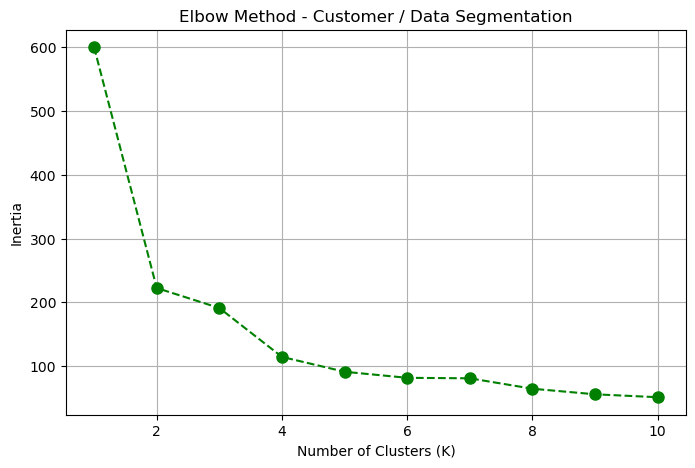

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


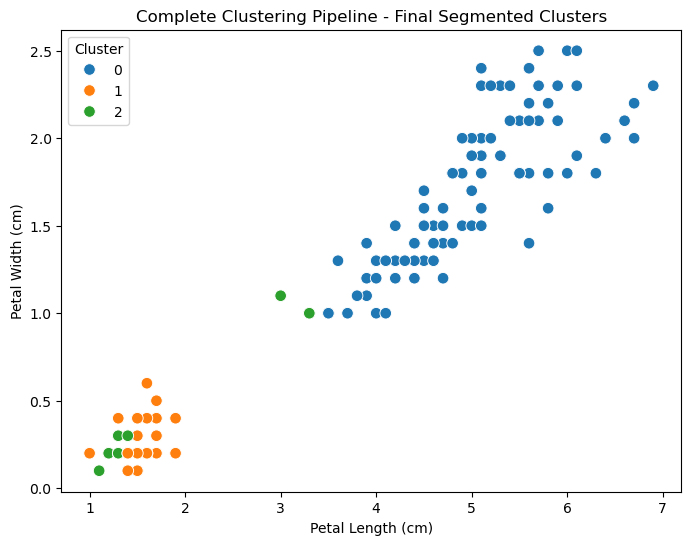

In [12]:
# Load and explore data
iris_proj = load_iris()
df_proj = pd.DataFrame(iris_proj.data, columns=['Sepal_Length', 'Sepal_Width', 'Petal_Length', 'Petal_Width'])
print("--- Step 1: Dataset Overview ---")
print(df_proj.head())

# Select numerical features and scale them
X_proj = df_proj[['Sepal_Length', 'Sepal_Width', 'Petal_Length', 'Petal_Width']]
scaler_proj = StandardScaler()
X_proj_scaled = scaler_proj.fit_transform(X_proj)

# Apply Elbow Method to find optimal K
proj_inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_proj_scaled)
    proj_inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), proj_inertia, 'go--', markersize=8)
plt.title('Elbow Method - Customer / Data Segmentation')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# Train final KMeans model (Optimal K = 3)
final_kmeans = KMeans(n_clusters=3, random_state=42)
df_proj['Cluster'] = final_kmeans.fit_predict(X_proj_scaled)

# Visualize clusters (using Petal Length vs Petal Width)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Petal_Length', y='Petal_Width', hue='Cluster', data=df_proj, palette='tab10', s=70)
plt.title('Complete Clustering Pipeline - Final Segmented Clusters')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.show()